# 03 - Deterministic Baseline

In this notebook I calculate the deterministic baseline for the cascaded cooling system.

The deterministic baseline is the conventional engineering assessment. It uses the nominal load values in the dataset and compares them directly with the available subsystem capacity.

This stage is important because it gives a reference point for the Monte Carlo simulation. The Monte Carlo model will later show how the result changes when uncertainty is introduced.

## Deterministic cascade method

The main risk in this notebook is double-counting the upstream loads.

The workbook contains embedded propagation rows:

* `ITEM_000955` is the HVAC load passed into CW.
* `ITEM_001103` is the CW load passed into FW.

Therefore, I do not sum all HVAC, CW and FW rows directly. Instead, I calculate the cascade using local downstream loads only:

```text
HVAC_total = sum(HVAC local loads)
CW_total   = HVAC_total + sum(CW local loads excluding ITEM_000955)
FW_total   = CW_total + sum(FW local loads excluding ITEM_001103)
```

This keeps the cascade structure while avoiding double-counting the embedded upstream transfer rows.

## Import libraries and set file paths

As with Notebook 02, I keep the code inside the notebook so that the calculation is reproducible and easy to follow from top to bottom.

In [1]:
# Importing the required libraries
from pathlib import Path
import pandas as pd
import numpy as np

# Plotting is useful for checking the deterministic result
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    plotting_available = True
except ModuleNotFoundError:
    plotting_available = False
    print("matplotlib and seaborn are not installed yet, so the table outputs will run but the graphs will be skipped.")

# Find the project root. This works if the notebook is run from the repo root or from the notebooks folder.
current_path = Path.cwd().resolve()
if (current_path / "data" / "raw" / "data.xlsx").exists():
    project_root = current_path
elif (current_path.parent / "data" / "raw" / "data.xlsx").exists():
    project_root = current_path.parent
else:
    raise FileNotFoundError("Could not find data/raw/data.xlsx. Please open VS Code at the repository folder.")

raw_data_path = project_root / "data" / "raw" / "data.xlsx"
tables_output_path = project_root / "outputs" / "tables"
figures_output_path = project_root / "outputs" / "figures"

tables_output_path.mkdir(parents=True, exist_ok=True)
figures_output_path.mkdir(parents=True, exist_ok=True)

print(f"Project root: {project_root}")
print(f"Raw data path: {raw_data_path}")
# Consistent project colours used in all notebook figures
SYSTEM_ORDER = ["HVAC", "CW", "FW"]
SYSTEM_PALETTE = {
    "HVAC": "#7b5aa6",
    "CW": "#3f83a3",
    "FW": "#5f9f77",
    "Ultimate Heat Sink": "#d78b4b",
}
SYSTEM_COLOUR_LIST = [SYSTEM_PALETTE[system] for system in SYSTEM_ORDER]
SCENARIO_PALETTE = {
    "Scenario Alpha": SYSTEM_PALETTE["HVAC"],
    "Scenario Bravo": SYSTEM_PALETTE["Ultimate Heat Sink"],
}
DISTRIBUTION_PALETTE = {
    "Triangular": SYSTEM_PALETTE["CW"],
    "Truncated normal": SYSTEM_PALETTE["Ultimate Heat Sink"],
}
DEPENDENCY_PALETTE = {
    "Independent": "#6f7b82",
    "Global Gaussian copula": SYSTEM_PALETTE["HVAC"],
    "Subsystem-block Gaussian copula": SYSTEM_PALETTE["CW"],
}


Project root: C:\Users\hburg\Documents\Codex\2026-06-26\github-plugin-github-openai-curated-remote\work\Monte-Carlo-Simulation-of-a-Cascading-Cooling-System
Raw data path: C:\Users\hburg\Documents\Codex\2026-06-26\github-plugin-github-openai-curated-remote\work\Monte-Carlo-Simulation-of-a-Cascading-Cooling-System\data\raw\data.xlsx


## Load the workbook

I load the same updated workbook used in Notebook 02. I inspect the sheet names and shape again so that the deterministic baseline is clearly linked to the current dataset.

In [2]:
# Load the workbook
excel_file = pd.ExcelFile(raw_data_path)
sheet_names = excel_file.sheet_names
raw_data = pd.read_excel(raw_data_path, sheet_name=sheet_names[0])

print("Sheet names in workbook:")
print(sheet_names)
print(f"Raw dataset shape: {raw_data.shape[0]} rows and {raw_data.shape[1]} columns")
display(raw_data.head())

Sheet names in workbook:
['data']
Raw dataset shape: 2457 rows and 37 columns


,PBS Code,Teamcenter ID,BOM ID,Item Description,HVAC Load,HVAC Scenario Alpha Lf,HVAC Scenario Alpha Uf,HVAC Scenario Alpha Load,HVAC Scenario Bravo Lf,HVAC Scenario Bravo Uf,...,FW Scenario Alpha Lf,FW Scenario Alpha Uf,FW Scenario Alpha Load,FW Scenario Bravo Lf,FW Scenario Bravo Uf,FW Scenario Bravo Load,FW CMM,FW CUM,FW DBM,FW IGM
0,PBS_GROUP_0001,NaN,BOM_000001,ITEM_000001,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PBS_GROUP_0001,NaN,BOM_000002,ITEM_000002,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PBS_GROUP_0001,NaN,BOM_000003,ITEM_000003,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,PBS_GROUP_0001,NaN,BOM_000004,ITEM_000004,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,PBS_GROUP_0001,NaN,BOM_000005,ITEM_000005,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Define capacities and expected checks

The capacity values are controlled model inputs. I define them directly in the notebook and save them as a table for traceability.

In [3]:
# Capacity assumptions provided for the project
capacity_table = pd.DataFrame({
    "subsystem": ["HVAC", "CW", "FW"],
    "scenario_alpha_capacity_kw": [1159.42, 4068.06, 11734.66],
    "scenario_bravo_capacity_kw": [372.93, 1392.08, 4871.78]
})

expected_deterministic_loads = {
    "HVAC": {"alpha": 1026.73, "bravo": 307.29},
    "CW": {"alpha": 3814.64, "bravo": 1256.64},
    "FW": {"alpha": 11172.39, "bravo": 4636.32}
}

capacity_table.to_csv(tables_output_path / "capacity_table.csv", index=False)
display(capacity_table)

,subsystem,scenario_alpha_capacity_kw,scenario_bravo_capacity_kw
0,HVAC,1159.42,372.93
1,CW,4068.06,1392.08
2,FW,11734.66,4871.78


## Check the embedded propagation rows

Before calculating the deterministic baseline, I check the two embedded propagation rows. This confirms which rows must be excluded from the local downstream sums.

In [4]:
# Identify the embedded propagation rows in the raw workbook
hvac_to_cw_rows = raw_data[raw_data["Item Description"] == "ITEM_000955"].copy()
cw_to_fw_rows = raw_data[raw_data["Item Description"] == "ITEM_001103"].copy()

propagation_check_columns = [
    "PBS Code", "Teamcenter ID", "BOM ID", "Item Description",
    "HVAC Scenario Alpha Load", "HVAC Scenario Bravo Load",
    "CW Scenario Alpha Load", "CW Scenario Bravo Load",
    "FW Scenario Alpha Load", "FW Scenario Bravo Load"
]

propagation_rows = pd.concat([hvac_to_cw_rows, cw_to_fw_rows], ignore_index=True)
propagation_rows = propagation_rows[propagation_check_columns]

propagation_rows.to_csv(tables_output_path / "deterministic_propagation_rows.csv", index=False)
display(propagation_rows)

,PBS Code,Teamcenter ID,BOM ID,Item Description,HVAC Scenario Alpha Load,HVAC Scenario Bravo Load,CW Scenario Alpha Load,CW Scenario Bravo Load,FW Scenario Alpha Load,FW Scenario Bravo Load
0,PBS_GROUP_0003,TC_000929,BOM_000975,ITEM_000955,NaN,NaN,1026.76,307.29,NaN,NaN
1,PBS_GROUP_0034,TC_001128,BOM_001173,ITEM_001103,NaN,NaN,NaN,NaN,3814.64,1256.64


## Calculate local loads

I first calculate the local load contribution for each subsystem.

For HVAC, all HVAC scenario load rows are local HVAC loads.

For CW, I exclude `ITEM_000955` because this is the embedded HVAC total row.

For FW, I exclude `ITEM_001103` because this is the embedded CW total row.

In [5]:
# Convert blank scenario fields to zero for deterministic summation
load_columns = [
    "HVAC Scenario Alpha Load", "HVAC Scenario Bravo Load",
    "CW Scenario Alpha Load", "CW Scenario Bravo Load",
    "FW Scenario Alpha Load", "FW Scenario Bravo Load"
]

deterministic_data = raw_data.copy()
for column in load_columns:
    deterministic_data[column] = pd.to_numeric(deterministic_data[column], errors="coerce").fillna(0)

# HVAC local loads
hvac_local_alpha = deterministic_data["HVAC Scenario Alpha Load"].sum()
hvac_local_bravo = deterministic_data["HVAC Scenario Bravo Load"].sum()

# CW local loads excluding the embedded HVAC-to-CW propagation row
cw_local_data = deterministic_data[deterministic_data["Item Description"] != "ITEM_000955"]
cw_local_alpha = cw_local_data["CW Scenario Alpha Load"].sum()
cw_local_bravo = cw_local_data["CW Scenario Bravo Load"].sum()

# FW local loads excluding the embedded CW-to-FW propagation row
fw_local_data = deterministic_data[deterministic_data["Item Description"] != "ITEM_001103"]
fw_local_alpha = fw_local_data["FW Scenario Alpha Load"].sum()
fw_local_bravo = fw_local_data["FW Scenario Bravo Load"].sum()

local_loads = pd.DataFrame({
    "subsystem": ["HVAC", "CW", "FW"],
    "scenario_alpha_local_load_kw": [hvac_local_alpha, cw_local_alpha, fw_local_alpha],
    "scenario_bravo_local_load_kw": [hvac_local_bravo, cw_local_bravo, fw_local_bravo]
})

local_loads.to_csv(tables_output_path / "deterministic_local_loads.csv", index=False)
display(local_loads)

,subsystem,scenario_alpha_local_load_kw,scenario_bravo_local_load_kw
0,HVAC,1026.733447,307.292472
1,CW,2787.878031,949.346198
2,FW,7357.754100,3379.678723


## Apply the cascade equations

I now apply the deterministic cascade. This is the main baseline calculation.

The key point is that the upstream total is added once at each downstream stage, after the embedded propagation row has been removed from the downstream local load sum.

In [6]:
# Scenario Alpha cascade
hvac_alpha_total = hvac_local_alpha
cw_alpha_total = hvac_alpha_total + cw_local_alpha
fw_alpha_total = cw_alpha_total + fw_local_alpha

# Scenario Bravo cascade
hvac_bravo_total = hvac_local_bravo
cw_bravo_total = hvac_bravo_total + cw_local_bravo
fw_bravo_total = cw_bravo_total + fw_local_bravo

deterministic_loads = pd.DataFrame({
    "subsystem": ["HVAC", "CW", "FW"],
    "scenario_alpha_load_kw": [hvac_alpha_total, cw_alpha_total, fw_alpha_total],
    "scenario_bravo_load_kw": [hvac_bravo_total, cw_bravo_total, fw_bravo_total]
})

deterministic_loads.to_csv(tables_output_path / "deterministic_cascade_loads.csv", index=False)
display(deterministic_loads)

,subsystem,scenario_alpha_load_kw,scenario_bravo_load_kw
0,HVAC,1026.733447,307.292472
1,CW,3814.611478,1256.638670
2,FW,11172.365578,4636.317393


## No-double-counting check

I include this check because it is the main engineering assumption in the project. The embedded propagation rows are excluded from the downstream local load sums, and the recomputed upstream totals are then added once through the cascade.

In [7]:
no_double_counting_check = pd.DataFrame([
    {
        "propagation_type": "hvac_to_cw",
        "embedded_row": "ITEM_000955",
        "downstream_system": "CW",
        "excluded_from_local_sum": True,
        "recomputed_upstream_alpha_kw": hvac_alpha_total,
        "embedded_alpha_kw": deterministic_data.loc[
            deterministic_data["Item Description"] == "ITEM_000955",
            "CW Scenario Alpha Load"
        ].sum(),
        "recomputed_upstream_bravo_kw": hvac_bravo_total,
        "embedded_bravo_kw": deterministic_data.loc[
            deterministic_data["Item Description"] == "ITEM_000955",
            "CW Scenario Bravo Load"
        ].sum()
    },
    {
        "propagation_type": "cw_to_fw",
        "embedded_row": "ITEM_001103",
        "downstream_system": "FW",
        "excluded_from_local_sum": True,
        "recomputed_upstream_alpha_kw": cw_alpha_total,
        "embedded_alpha_kw": deterministic_data.loc[
            deterministic_data["Item Description"] == "ITEM_001103",
            "FW Scenario Alpha Load"
        ].sum(),
        "recomputed_upstream_bravo_kw": cw_bravo_total,
        "embedded_bravo_kw": deterministic_data.loc[
            deterministic_data["Item Description"] == "ITEM_001103",
            "FW Scenario Bravo Load"
        ].sum()
    }
])

no_double_counting_check["alpha_difference_kw"] = (
    no_double_counting_check["recomputed_upstream_alpha_kw"] - no_double_counting_check["embedded_alpha_kw"]
)
no_double_counting_check["bravo_difference_kw"] = (
    no_double_counting_check["recomputed_upstream_bravo_kw"] - no_double_counting_check["embedded_bravo_kw"]
)

no_double_counting_check.to_csv(tables_output_path / "deterministic_no_double_counting_check.csv", index=False)
display(no_double_counting_check)

,propagation_type,embedded_row,downstream_system,excluded_from_local_sum,recomputed_upstream_alpha_kw,embedded_alpha_kw,recomputed_upstream_bravo_kw,embedded_bravo_kw,alpha_difference_kw,bravo_difference_kw
0,hvac_to_cw,ITEM_000955,CW,True,1026.733447,1026.76,307.292472,307.29,-0.026553,0.002472
1,cw_to_fw,ITEM_001103,FW,True,3814.611478,3814.64,1256.638670,1256.64,-0.028522,-0.001330


## Check against embedded workbook totals

I also compare the recomputed cascade totals against the raw workbook totals. This is a useful validation check because the updated workbook already contains the embedded upstream transfer rows.

I use the recomputed cascade as the main method because it makes the no-double-counting rule explicit. Small differences between the recomputed total and the embedded workbook total are expected where the workbook propagation row is rounded.

In [8]:
# Raw workbook totals include the embedded propagation rows
raw_workbook_totals = pd.DataFrame({
    "subsystem": ["HVAC", "CW", "FW"],
    "scenario_alpha_raw_workbook_total_kw": [
        deterministic_data["HVAC Scenario Alpha Load"].sum(),
        deterministic_data["CW Scenario Alpha Load"].sum(),
        deterministic_data["FW Scenario Alpha Load"].sum()
    ],
    "scenario_bravo_raw_workbook_total_kw": [
        deterministic_data["HVAC Scenario Bravo Load"].sum(),
        deterministic_data["CW Scenario Bravo Load"].sum(),
        deterministic_data["FW Scenario Bravo Load"].sum()
    ]
})

cascade_check = deterministic_loads.merge(raw_workbook_totals, on="subsystem")
cascade_check["scenario_alpha_recomputed_minus_raw_kw"] = (
    cascade_check["scenario_alpha_load_kw"] - cascade_check["scenario_alpha_raw_workbook_total_kw"]
)
cascade_check["scenario_bravo_recomputed_minus_raw_kw"] = (
    cascade_check["scenario_bravo_load_kw"] - cascade_check["scenario_bravo_raw_workbook_total_kw"]
)

cascade_check.to_csv(tables_output_path / "deterministic_cascade_vs_workbook_check.csv", index=False)
display(cascade_check)

,subsystem,scenario_alpha_load_kw,scenario_bravo_load_kw,scenario_alpha_raw_workbook_total_kw,scenario_bravo_raw_workbook_total_kw,scenario_alpha_recomputed_minus_raw_kw,scenario_bravo_recomputed_minus_raw_kw
0,HVAC,1026.733447,307.292472,1026.733447,307.292472,0.000000,0.000000
1,CW,3814.611478,1256.638670,3814.638031,1256.636198,-0.026553,0.002472
2,FW,11172.365578,4636.317393,11172.394100,4636.318723,-0.028522,-0.001330


## Check against expected deterministic values

I compare the deterministic totals with the expected values from the project notes. This is a sanity check rather than a hardcoded answer.

In [9]:
expected_rows = []

for _, row in deterministic_loads.iterrows():
    subsystem = row["subsystem"]
    for scenario in ["alpha", "bravo"]:
        calculated_load = row[f"scenario_{scenario}_load_kw"]
        expected_load = expected_deterministic_loads[subsystem][scenario]
        expected_rows.append({
            "subsystem": subsystem,
            "scenario": scenario,
            "calculated_load_kw": calculated_load,
            "expected_load_kw": expected_load,
            "calculated_minus_expected_kw": calculated_load - expected_load
        })

expected_check = pd.DataFrame(expected_rows)
expected_check.to_csv(tables_output_path / "deterministic_expected_load_check.csv", index=False)
display(expected_check)

,subsystem,scenario,calculated_load_kw,expected_load_kw,calculated_minus_expected_kw
0,HVAC,alpha,1026.733447,1026.73,0.003447
1,HVAC,bravo,307.292472,307.29,0.002472
2,CW,alpha,3814.611478,3814.64,-0.028522
3,CW,bravo,1256.638670,1256.64,-0.001330
4,FW,alpha,11172.365578,11172.39,-0.024422
5,FW,bravo,4636.317393,4636.32,-0.002607


## Compare deterministic loads with capacity

I now compare each deterministic subsystem load against the available capacity.

The deterministic pass/fail rule is:

```text
pass if load <= capacity
fail if load > capacity
```

I also calculate spare capacity, capacity margin percentage, and load-to-capacity ratio.

In [10]:
baseline_rows = []

for _, load_row in deterministic_loads.iterrows():
    subsystem = load_row["subsystem"]
    capacity_row = capacity_table[capacity_table["subsystem"] == subsystem].iloc[0]

    for scenario in ["alpha", "bravo"]:
        load_kw = load_row[f"scenario_{scenario}_load_kw"]
        capacity_kw = capacity_row[f"scenario_{scenario}_capacity_kw"]
        spare_capacity_kw = capacity_kw - load_kw
        capacity_margin_pct = spare_capacity_kw / capacity_kw * 100
        load_to_capacity_ratio = load_kw / capacity_kw

        baseline_rows.append({
            "scenario": f"Scenario {scenario.title()}",
            "subsystem": subsystem,
            "deterministic_load_kw": load_kw,
            "capacity_kw": capacity_kw,
            "spare_capacity_kw": spare_capacity_kw,
            "capacity_margin_pct": capacity_margin_pct,
            "load_to_capacity_ratio": load_to_capacity_ratio,
            "pass_fail": "Pass" if load_kw <= capacity_kw else "Fail"
        })

deterministic_baseline = pd.DataFrame(baseline_rows)
deterministic_baseline.to_csv(tables_output_path / "deterministic_baseline.csv", index=False)
display(deterministic_baseline)

,scenario,subsystem,deterministic_load_kw,capacity_kw,spare_capacity_kw,capacity_margin_pct,load_to_capacity_ratio,pass_fail
0,Scenario Alpha,HVAC,1026.733447,1159.42,132.686553,11.444218,0.885558,Pass
1,Scenario Bravo,HVAC,307.292472,372.93,65.637528,17.600496,0.823995,Pass
2,Scenario Alpha,CW,3814.611478,4068.06,253.448522,6.230206,0.937698,Pass
3,Scenario Bravo,CW,1256.638670,1392.08,135.441330,9.729421,0.902706,Pass
4,Scenario Alpha,FW,11172.365578,11734.66,562.294422,4.791740,0.952083,Pass
5,Scenario Bravo,FW,4636.317393,4871.78,235.462607,4.833195,0.951668,Pass


## Identify the most constrained subsystem

The most constrained subsystem is the one with the lowest deterministic capacity margin percentage in each scenario.

In [11]:
most_constrained = (
    deterministic_baseline
    .sort_values(["scenario", "capacity_margin_pct"])
    .groupby("scenario")
    .head(1)
    .reset_index(drop=True)
)

most_constrained.to_csv(tables_output_path / "deterministic_most_constrained_subsystems.csv", index=False)
display(most_constrained)

,scenario,subsystem,deterministic_load_kw,capacity_kw,spare_capacity_kw,capacity_margin_pct,load_to_capacity_ratio,pass_fail
0,Scenario Alpha,FW,11172.365578,11734.66,562.294422,4.791740,0.952083,Pass
1,Scenario Bravo,FW,4636.317393,4871.78,235.462607,4.833195,0.951668,Pass


## Visualise deterministic load against capacity

The plot below compares deterministic load and capacity for each subsystem and scenario. This is useful for checking whether the deterministic assessment passes while still being close to capacity.

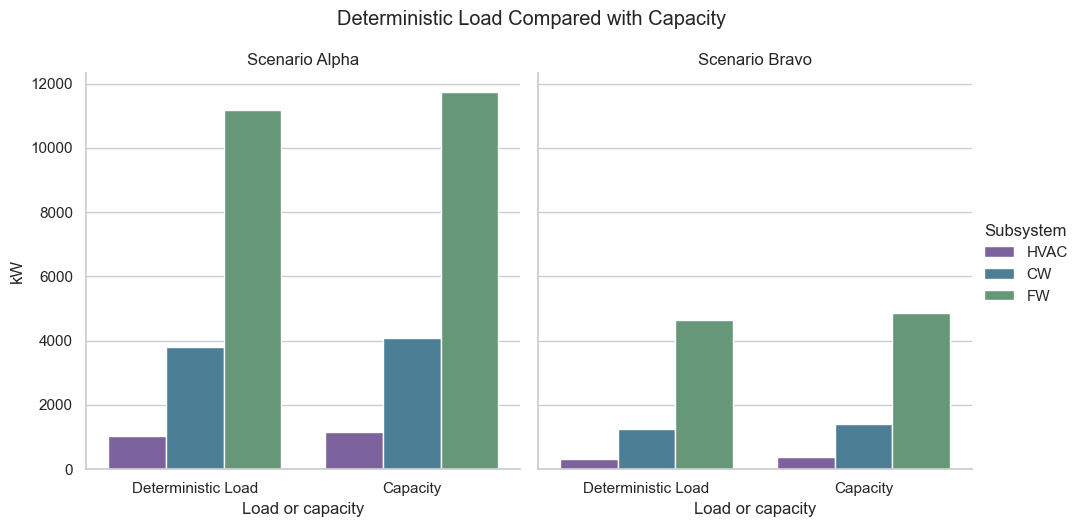

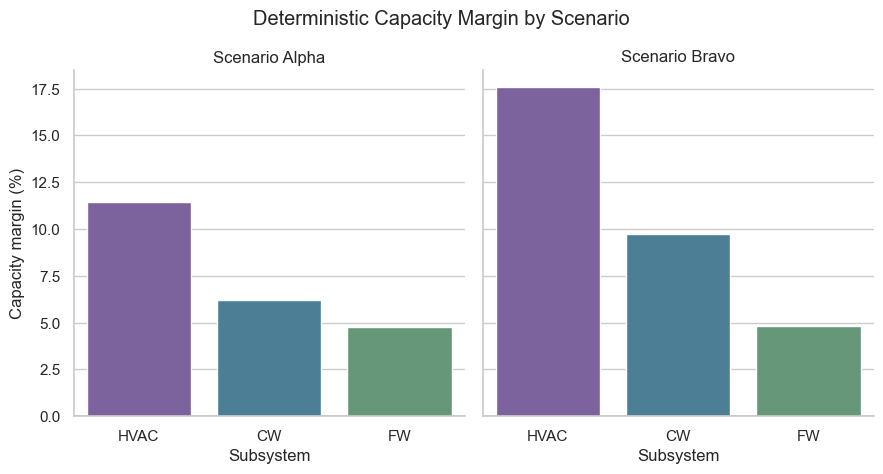

In [12]:
if plotting_available:
    sns.set_theme(style="whitegrid")

    plot_data = deterministic_baseline.melt(
        id_vars=["scenario", "subsystem"],
        value_vars=["deterministic_load_kw", "capacity_kw"],
        var_name="measure",
        value_name="kw"
    )

    plot_data["measure"] = plot_data["measure"].replace({
        "deterministic_load_kw": "Deterministic Load",
        "capacity_kw": "Capacity"
    })

    graph = sns.catplot(
        data=plot_data,
        x="measure",
        y="kw",
        hue="subsystem",
        col="scenario",
        hue_order=SYSTEM_ORDER,
        palette=SYSTEM_PALETTE,
        kind="bar",
        height=5,
        aspect=1,
    )
    graph.fig.suptitle("Deterministic Load Compared with Capacity", y=1.05)
    graph.set_axis_labels("Load or capacity", "kW")
    graph.set_titles("{col_name}")
    if graph._legend is not None:
        graph._legend.set_title("Subsystem")
    graph.savefig(figures_output_path / "deterministic_load_vs_capacity.png", dpi=150, bbox_inches="tight")
    plt.show()

    graph = sns.catplot(
        data=deterministic_baseline,
        x="subsystem",
        y="capacity_margin_pct",
        hue="subsystem",
        col="scenario",
        order=SYSTEM_ORDER,
        hue_order=SYSTEM_ORDER,
        palette=SYSTEM_PALETTE,
        kind="bar",
        height=4.5,
        aspect=1.0,
        dodge=False,
        legend=False,
        sharey=True,
    )
    graph.fig.suptitle("Deterministic Capacity Margin by Scenario", y=1.05)
    graph.set_axis_labels("Subsystem", "Capacity margin (%)")
    graph.set_titles("{col_name}")
    for axis in graph.axes.flat:
        axis.axhline(0, color="black", linewidth=1)
    graph.savefig(figures_output_path / "deterministic_capacity_margin.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Skipping plots because matplotlib and seaborn are not installed in this Python environment.")


## Deterministic baseline interpretation

The deterministic assessment shows whether the system passes under nominal loading only. It does not quantify the probability of overload under uncertainty, but it identifies which subsystems are closest to capacity before uncertainty is introduced.

Based on the calculated deterministic baseline:

* all subsystems pass in Scenario Alpha and Scenario Bravo;
* FW is the most constrained subsystem in both scenarios;
* the capacity margins are small enough that probabilistic modelling is useful, because uncertainty could change the risk interpretation even where the deterministic result passes.

The next notebook should define how uncertainty is represented around the nominal load values before the Monte Carlo simulation is built.